In [394]:
#import packages
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import os
import yaml
import itertools
import shutil
from datetime import datetime
from pathlib import Path
from openpyxl.styles import PatternFill
from openpyxl import load_workbook
from collections import defaultdict
import sys
from openpyxl.styles import Border, Side
from openpyxl.styles import Alignment, Font
from openpyxl.utils import get_column_letter
from numpy._core.numeric import indices
from tqdm import tqdm
from functools import lru_cache
from collections import deque
import networkx as nx
from collections import Counter


#set working dir
os.chdir("/Users/quinnmackay/Documents/GitHub/BICC/Antarctic Chronology Accuracy Project")

In [395]:
# load cores
project = 'Bipolar'
output_dir = 'table_out/'

# get all link combos
with open(f'/Users/quinnmackay/Documents/GitHub/BICC/Antarctic Chronology Accuracy Project/{project}/parameters.yml') as f:
    data = yaml.safe_load(f)
list_sites = data["list_sites"]
pairs = [f"{a}-{b}" for a, b in itertools.combinations(list_sites, 2)]

#define error margins
error_margin = 0.15

In [396]:
big_table = pd.DataFrame()
all_links_count = {}
all_links_foragesort = {}
all_links_total = {}

for core in list_sites: # loop through each core
    for comparison_core in list_sites: # loop through each core other than the initial load
        pair = f"{core}-{comparison_core}"
        if core != comparison_core and pair in pairs: # make sure not the same core and we skip non-existent linkages
            pair_dir = Path(f'/Users/quinnmackay/Documents/GitHub/BICC/Antarctic Chronology Accuracy Project/{project}/{pair}')

            # Check: directory exists AND contains at least one .txt file
            txt_files = list(pair_dir.glob("*.txt"))
            if not pair_dir.is_dir() or not txt_files:
                continue

            dfs=[] #load all text files into one
            for txt in txt_files:
                df = pd.read_csv(txt, sep="\t", comment="#")
                dfs.append(df)
    
            num_files = len(dfs)
            load_data = pd.concat(dfs, ignore_index=True)
            original_rows = len(load_data)

            drop_rows = []
            drop_rows_merge = set()
            new_merged_rows = []
            for idx, row in load_data.iterrows():

                mask1 = abs(row['depth1'] - load_data['depth1']) <= error_margin
                mask1[idx] = False
                mask2 = abs(row['depth2'] - load_data['depth2']) <= error_margin 
                mask2[idx] = False

                close_points = load_data[mask1 & mask2]
                num_close = len(close_points)
                close_idxs = load_data.index[mask1 & mask2]

                if num_close > 0:
                    refs = [load_data.at[idx, 'reference']] + [load_data.at[i, 'reference'] for i in close_idxs] #adjoin references
                    merged_ref = "; ".join(str(r) for r in refs if pd.notna(r))

                    depth1_vals = [load_data.at[idx, 'depth1']] + [load_data.at[i, 'depth1'] for i in close_idxs]
                    merged_depth1 = np.round(np.mean(depth1_vals), 4)

                    depth2_vals = [load_data.at[idx, 'depth2']] + [load_data.at[i, 'depth2'] for i in close_idxs]
                    merged_depth2 = np.round(np.mean(depth2_vals), 4)

                    new_merged_rows.append({'reference': merged_ref, 'depth1': merged_depth1, 'depth2': merged_depth2}) #create new merged row

                    drop_rows_merge.add(idx)
                    for i in close_idxs:
                        drop_rows.append(i)
                        if drop_rows.count(i) >= num_files:
                            print(f'WARNING: Row {load_data.at[i, 'depth1']} | {load_data.at[i, 'depth2']} for {pair}. Reference {load_data.at[i, 'reference']}.')
                            print(f'Called by row {load_data.at[idx, 'depth1']} | {load_data.at[idx, 'depth2']} from reference {load_data.at[idx, 'reference']}.')

            # drop duplicate rows
            drop_rows = set(drop_rows).union(drop_rows_merge)
            load_data = load_data.drop(index=drop_rows).reset_index(drop=True)
            # add merged rows
            merged_df = pd.DataFrame(new_merged_rows)
            load_data = pd.concat([load_data, merged_df], ignore_index=True)
            load_data.drop_duplicates(subset=['depth1', 'depth2'], inplace=True)
            load_data = load_data.reset_index(drop=True)

            load_data = load_data.sort_values(by=['depth1']).reset_index(drop=True)
        
            #set up pair code stuff
            load_data[f"{pair}_code"] = [f"{pair}_{idx}" for idx in load_data.index]

            #save all the links for this pair
            all_links_total[f'{pair}'] = load_data[['depth1', 'depth2']].copy(deep=True)
            all_links_total[f'{pair}'] = all_links_total[f'{pair}'].rename(columns={
                'depth1': pair.split("-")[0],
                'depth2': pair.split("-")[1]})

            # rename to create unique columns for this pair
            load_data = load_data.rename(columns={
                'depth1': f"{pair}_{core}",
                'depth2': f"{pair}_{comparison_core}",
                'reference': f"{pair}_reference",
            })

            print(f"Processed pair {pair}, total points after merging: {len(load_data)}, ({original_rows} original total rows)")
            # append rows (block)
            big_table = pd.concat([big_table, load_data], axis=0, ignore_index=True)

#if core doesn't exist in all_links_count, add it with 0 val
for core in list_sites:
    if core not in all_links_count:
        all_links_count[core] = 0

Processed pair GISP2-DF, total points after merging: 118, (118 original total rows)
Processed pair GISP2-TALDICE, total points after merging: 89, (89 original total rows)
Processed pair GISP2-EDC, total points after merging: 138, (138 original total rows)
Processed pair GISP2-EDML, total points after merging: 155, (155 original total rows)
Processed pair GISP2-WDC, total points after merging: 286, (299 original total rows)
Processed pair GRIP-DF, total points after merging: 107, (107 original total rows)
Processed pair GRIP-TALDICE, total points after merging: 74, (74 original total rows)
Processed pair GRIP-EDC, total points after merging: 119, (119 original total rows)
Processed pair GRIP-EDML, total points after merging: 127, (127 original total rows)
Processed pair GRIP-WDC, total points after merging: 184, (296 original total rows)
Processed pair NEEM-DF, total points after merging: 132, (132 original total rows)
Processed pair NEEM-TALDICE, total points after merging: 86, (86 ori

In [397]:
def get_core_pair(node): #takes a node (which is a tuple of (index, root_core)) and outputs the other pair in the same row of big_table
    idx, root_core = node

    core1, core2 = get_row_cores(idx)
    if core1 == root_core: #if the first part of the pair is the root core, return the second part
        root_core_pair = core2
    elif core2 == root_core: #if the second part of the pair is the root core, return the first part
        root_core_pair = core1
    else: #just in case
        sys.exit(f"ERROR: Could not determine root core pair for root core {root_core}.")

    return root_core_pair

def readable_paths(paths): #takes a list of paths (which are lists of tuples of (pair, core)) and outputs a list of paths in the format "core1-core2 and the index"
    readable_all = []
    for root_core, path in paths: #paths is a list of (root_core, (list of tuples of (pair, core)))
        readable = []
        root = root_core[1]

        for i, p in enumerate(path):
            if i == 0:
                readable.append(f"{root}-{p[1]} ({p[0]})") #for the first pair, use the root core and the other core in the pair
            else:
                readable.append(f"{path[i-1][1]}-{p[1]} ({p[0]})") #for subsequent pairs, use the previous core and the other core in the pair
        readable_all.append(readable)

    return readable_all

In [398]:
@lru_cache(maxsize=None)
def _non_zero_columns(index):
    row_vals = big_table.loc[index]
    return tuple(row_vals[(row_vals.notna()) & (row_vals != 0)].index.tolist())

@lru_cache(maxsize=None)
def _row_pair_info(index):
    non_zero_columns = _non_zero_columns(index)
    if not non_zero_columns:
        print(f"No active columns found for row {index}.")
        sys.exit()

    pair_name = non_zero_columns[0].split("_")[0]
    core1, core2 = pair_name.split("-")
    return pair_name, core1, core2

@lru_cache(maxsize=None)
def _row_core_column(index, core):
    non_zero_columns = _non_zero_columns(index)
    for col in non_zero_columns:
        if col.endswith(core):
            return col

    print(f"No active columns found for core {core} in row {index}.")
    sys.exit()

def get_row_cores(index):
    _, core1, core2 = _row_pair_info(index)
    return core1, core2

@lru_cache(maxsize=None)
def get_depth(core, index): #function to grab the depth based on core and index
    column_name = _row_core_column(index, core)
    return big_table.at[index, column_name]

@lru_cache(maxsize=None)
def get_code(index): #function to grab the code based on index
    non_zero_columns = _non_zero_columns(index)

    code_columns = [c for c in non_zero_columns if c.endswith("code")]
    if not code_columns:
        print(f"No code column found for row {index}.")
        sys.exit()

    return big_table.at[index, code_columns[0]]

@lru_cache(maxsize=None)
def get_reference(index): #function to grab the reference based on index
    non_zero_columns = _non_zero_columns(index)

    reference_columns = [c for c in non_zero_columns if c.endswith("reference")]
    if not reference_columns:
        print(f"No reference column found for row {index}.")
        sys.exit()

    return big_table.at[index, reference_columns[0]]

In [399]:
def _build_core_match_cache():
    core_match_cache = defaultdict(list)

    for column in big_table.columns:
        if column.endswith("_reference") or column.endswith("_code"):
            continue

        pair_name = column.split("_")[0]
        if "-" not in pair_name:
            continue

        core1, core2 = pair_name.split("-")
        column_core = column.rsplit("_", 1)[-1]
        if column_core not in (core1, core2):
            continue

        if core1 != column_core: #if the first part of the pair is not the core name, then it must be the matching core
            matching_core = core1
        elif core2 != column_core: #if the second part of the pair is not the core name, then it must be the matching core
            matching_core = core2
        else:
            print(f"ERROR: Could not determine matching core for column {column}.")
            sys.exit()

        series = big_table[column]
        valid_mask = series.notna()
        valid_indices = series.index[valid_mask].to_numpy(dtype=np.int64, copy=True)
        valid_values = series[valid_mask].to_numpy(dtype=float, copy=True)
        core_match_cache[column_core].append((valid_indices, valid_values, matching_core))

    return core_match_cache

CORE_MATCH_CACHE = _build_core_match_cache()

def find_matches(index, core_name): # Find the matches for a given index, core_name. Outputs a list of matching indices and their associated core names.
    match_indices = []  # empty array
    match_cores = [] # empty array

    core_value = get_depth(core_name, index)  # get value of core in current row

    for valid_indices, valid_values, matching_core in CORE_MATCH_CACHE.get(core_name, []):
        matches = np.abs(valid_values - core_value) <= error_margin
        if np.any(matches):
            found = valid_indices[matches]
            match_indices.extend(found.tolist())
            match_cores.extend([matching_core] * len(found))

    return match_indices, match_cores

@lru_cache(maxsize=None)
def find_matches_cached(index, core_name): #cache the find_matches function to speed up calls
    return find_matches(index, core_name)

def bfs(root_index, root_core, *, max_floor=20): #breadth-first-search
    root = (root_index, root_core) #create root node as a tuple of (index, core)
    root_pair = (root_index, get_core_pair(root)) #create root pair as a tuple of (index, core pair) using the get_core_pair function to find the core pair for the root core

    queue = deque([(root_pair[0], root_pair[1], None)]) #store nodes as (index, core, parent_node_id)
    next_floor = deque() #this will be used to store the nodes for the next floor as we find matches for the current floor
    network = [] #creates empty network variable
    current_floor_number = 0 #start at floor zero, which is the root node
    export_pathways = [] #store the pathways found for export
    node_records = [] #stores (index, core, parent_node_id)

    while queue: #while there are still nodes to explore in the queue

        if current_floor_number > max_floor: #if we have exceeded the maximum floor,
            break

        floor_width = len(queue) #the width of the current floor is the number of nodes in the queue at the start of the floor
        for _ in range(floor_width): #for each node in the current floor
            idx, core, parent_node_id = queue.popleft() #current node removes from left of queue
            node = (idx, core)

            existing_path = []
            extracted_numbers = []
            parent_cursor = parent_node_id
            while parent_cursor is not None:
                parent_idx, parent_core, next_parent = node_records[parent_cursor]
                existing_path.append((parent_idx, parent_core))
                extracted_numbers.append(parent_idx)
                parent_cursor = next_parent

            # Reset per-node state to avoid leaking values from the previous node.
            match_indices, match_cores = [], []
            terminate_path = False

            if idx in extracted_numbers: #if index already exists in this path, stop and export
                terminate_path = True
                export_pathways.append((root, list(reversed(existing_path)) + [node])) #add the root and the existing path to the export pathways
            else:
                # If we revisit the same core, only terminate when this is effectively the same event.
                if core in (c for _, c in existing_path):
                    visited_same_core = next((n for n in existing_path if n[1] == core), None) #get the core that we have previously visited
                    same_core_depth = get_depth(visited_same_core[1], visited_same_core[0])
                    current_core_depth = get_depth(core, idx)
                    if abs(same_core_depth - current_core_depth) < error_margin:
                        terminate_path = True
                        export_pathways.append((root, list(reversed(existing_path)) + [node])) #add the root and the existing path to the export pathways

                if (not terminate_path) and (core == root_core): #looped back to root core
                    terminate_path = True
                    export_pathways.append((root, list(reversed(existing_path)) + [node])) #add the root and the existing path to the export pathways

                if not terminate_path:
                    match_indices, match_cores = find_matches_cached(idx, core) #find matches for the current node

            current_node_id = len(node_records)
            node_records.append((idx, core, parent_node_id))

            if not terminate_path:
                next_floor.extend((match_idx, match_core, current_node_id) for match_idx, match_core in zip(match_indices, match_cores)) #add matches to next floor

            network.append((current_floor_number, idx, core, len(match_indices)))  #the full network, saved but not used.

        current_floor_number += 1 #increment floor number after exploring all nodes in the current floor
        queue.extend(next_floor) #add the nodes for the next floor to the queue to explore in the next iteration of the while loop
        next_floor.clear() #clear the next floor for the next iteration

    return export_pathways, network

In [400]:
# for each row, start DFS from each core on that row
every_path = []
for index in tqdm(big_table.index, total=len(big_table), desc="DFS", unit="row", position=0): #for each row in big_table
    core1, core2 = get_row_cores(index) #names of the cores

    for core in (core1, core2): #for each core

        paths, network = bfs(index, core, max_floor=12) #get paths and network from BFS
        every_path.extend(paths)

DFS: 100%|██████████| 3233/3233 [00:09<00:00, 352.72row/s]


In [401]:
error_networks = 0 #number of error networks
circular_networks = 0 #total number of circular networks

naughty_list = set() #use sets for unique values
nice_list = set()

for path in tqdm(every_path, total=len(every_path), desc="Getting depths", unit="path"): #for each path in every_path, get the root core and end node core, and if they are the same, check if the depth difference is within the error margin.

    root_core = path[0][1] #gets the root core
    root_index = path[0][0] #gets the root index

    end_node_core = path[1][-1][1] #gets the end node core, which is the core of the last node in the path
    end_node_index = path[1][-1][0] #get the end node index, which is the index of the last node in the path

    all_indices = [node[0] for node in path[1]] #gets all the indices in the path, which will be used to add to the naughty or nice list depending on whether this path is an error network or not

    if root_core != end_node_core: #if not circular, skip
        continue

    if len(all_indices) < 3: #if the path is too short to be successful, skip
        continue

    else:

        circular_networks += 1 #add to toal cicular
        root_depth = get_depth(root_core, root_index) #get the root depth
        end_node_depth = get_depth(end_node_core, end_node_index) #get the end node depth
        if abs(root_depth - end_node_depth) >= error_margin: #if depths differ more than by error margin, error network
            error_networks += 1

            for idx in all_indices: #put all the indices in the naughty list, unless in nice list
                if idx in nice_list:
                    continue
                else:
                    if get_code(idx) == 'NG2-EDML_311':
                        print(path)
                    naughty_list.add(idx)

        elif abs(root_depth - end_node_depth) <= error_margin: #else, everything into nice list

            for idx in all_indices:
                nice_list.add(idx)
                if idx in naughty_list:
                    naughty_list.remove(idx)


Getting depths:  93%|█████████▎| 3566656/3827119 [00:01<00:00, 3374919.90path/s]

((2311, 'NG2'), [(2311, 'DF'), (891, 'GRIP'), (1210, 'EDML'), (3029, 'NG2')])
((2311, 'NG2'), [(2311, 'DF'), (1524, 'NEEM'), (1764, 'EDC'), (1084, 'GRIP'), (1210, 'EDML'), (3029, 'NG2')])
((2311, 'NG2'), [(2311, 'DF'), (1524, 'NEEM'), (1932, 'EDML'), (1211, 'GRIP'), (1210, 'EDML'), (3029, 'NG2')])
((2707, 'NG2'), [(2707, 'EDC'), (1084, 'GRIP'), (1210, 'EDML'), (3029, 'NG2')])
((2707, 'NG2'), [(2707, 'EDC'), (1764, 'NEEM'), (1524, 'DF'), (891, 'GRIP'), (1210, 'EDML'), (3029, 'NG2')])
((2707, 'NG2'), [(2707, 'EDC'), (1764, 'NEEM'), (1932, 'EDML'), (1211, 'GRIP'), (1210, 'EDML'), (3029, 'NG2')])
((3029, 'NG2'), [(3029, 'EDML'), (1210, 'GRIP'), (891, 'DF'), (2311, 'NG2')])
((3029, 'NG2'), [(3029, 'EDML'), (1210, 'GRIP'), (1084, 'EDC'), (2707, 'NG2')])
((3029, 'NG2'), [(3029, 'EDML'), (1210, 'GRIP'), (1211, 'EDML'), (3030, 'NG2')])
((3029, 'NG2'), [(3029, 'EDML'), (1210, 'GRIP'), (891, 'DF'), (1524, 'NEEM'), (1764, 'EDC'), (2707, 'NG2')])
((3029, 'NG2'), [(3029, 'EDML'), (1210, 'GRIP'), (89

Getting depths: 100%|██████████| 3827119/3827119 [00:01<00:00, 3238705.01path/s]


In [402]:
target_path = ((2311, 'NG2'), [(2311, 'DF'), (891, 'GRIP'), (1210, 'EDML'), (3029, 'NG2')])

# root
print(f"{target_path[0][1]} - ", get_depth(target_path[0][1], target_path[0][0]))

# path nodes
for idx, core in target_path[1]:
    print(f"{core} - ", get_depth(core, idx))

NG2 -  2898.54
DF -  1502.15
GRIP -  2753.24
EDML -  2193.45
NG2 -  2897.2


In [403]:
#Code to check for first order errors (aka two cores with one side within 0.15 and the other not)
print(f"naughty: {len(naughty_list)}")
print(f"nice: {len(nice_list)}")

#creating a new set to avoid modifying original set
appended_naughty = set(naughty_list)
all_first_order = set()

#create lists
row_index_list = []
group_key_list = []
depth1_list = []
depth2_list = []

#for every row in big_table
for idx, row in big_table.iterrows():
    row = row.dropna()
    row_index_list.append(idx) #
    group_key_list.append(row.index[0])   # (example: EDC-WDC_0), these are the keys to sort by
    depth1_list.append(row.iloc[0]) #append depths
    depth2_list.append(row.iloc[1])

groups = defaultdict(list)
for position, group_key in enumerate(group_key_list):
    groups[group_key].append(position) #create groups for each pair, and then add the position (effectively idx) in the arrays

for group_key, positions in tqdm(groups.items(), total=len(groups), desc="First Order Errors (grouped)", unit="group"): #go group by group
    pos_arr = np.array(positions, dtype=np.int64)
    idx_arr = np.array([row_index_list[p] for p in positions], dtype=np.int64)
    depth1_arr = np.array([depth1_list[p] for p in positions], dtype=float)
    depth2_arr = np.array([depth2_list[p] for p in positions], dtype=float)

    check1 = np.abs(depth1_arr[:, None] - depth1_arr[None, :]) <= error_margin
    check2 = np.abs(depth2_arr[:, None] - depth2_arr[None, :]) <= error_margin
    xor_matrix = np.logical_xor(check1, check2)
    np.fill_diagonal(xor_matrix, False)

    for row_i, idx in enumerate(idx_arr):
        flagged = np.flatnonzero(xor_matrix[row_i])
        for col_j in flagged:
            idx_check = idx_arr[col_j] #get the index to check against
            all_first_order.add(idx_check)
            all_first_order.add(idx)
            if idx_check in nice_list: #don't add to naughty list if in nice list
                continue
            appended_naughty.add(idx_check)
            appended_naughty.add(idx)


naughty: 6
nice: 2561


First Order Errors (grouped): 100%|██████████| 21/21 [00:00<00:00, 4630.69group/s]


In [404]:
#print percentage naughty overall
print(f"Statistics concerning the '{project}' networks")
print(f"Total tiepoints: {len(big_table)}")
print(f"Total naughty: {len(appended_naughty)}")
print(f"Total nice: {len(nice_list)}")
print(f"Percentage naughty: {100*len(appended_naughty)/len(big_table):.2f}%")
print(f"Percentage nice: {100*len(nice_list)/len(big_table):.2f}%")

Statistics concerning the 'Bipolar' networks
Total tiepoints: 3233
Total naughty: 14
Total nice: 2561
Percentage naughty: 0.43%
Percentage nice: 79.21%


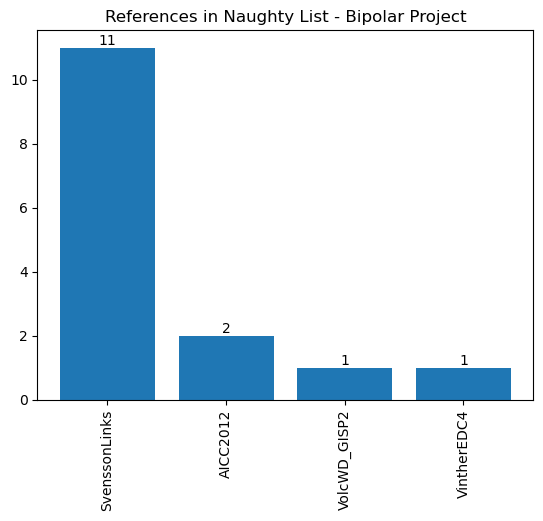

In [405]:
#reference bar plot

refs = []
for idx in appended_naughty:
    ref = get_reference(idx)
    r_split = ref.split("; ")
    for r in r_split:
        refs.append(r)

counts = Counter(refs) #this counts the number of occurrences of each reference in the refs list

sorted_items = sorted(counts.items(), key=lambda x: x[1], reverse=True)
labels = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]

plt.figure()
bars = plt.bar(labels, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=90)
plt.title(f"References in Naughty List - {project} Project")
plt.show()

13


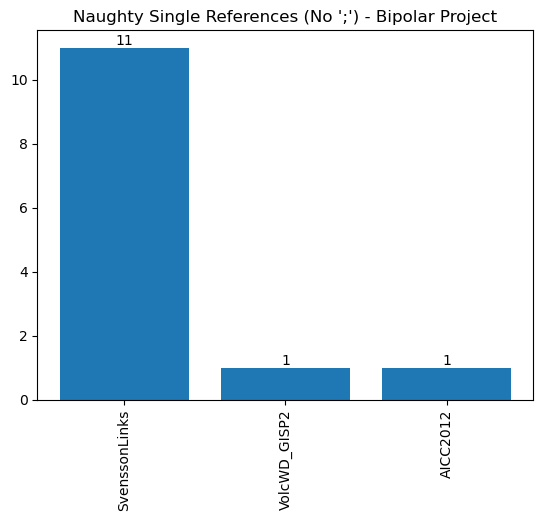

In [406]:
# reference bar plot (only single references — no ';')

full_refs_grab = []
for idx in appended_naughty:
    ref = get_reference(idx)
    full_refs_grab.append(ref)

single_refs = [r for r in full_refs_grab if ";" not in r]

print(len(single_refs))
counts_single = Counter(single_refs)

sorted_items = sorted(counts_single.items(), key=lambda x: x[1], reverse=True)
labels = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]

plt.figure()
bars = plt.bar(labels, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=90)
plt.title(f"Naughty Single References (No ';') - {project} Project")
plt.show()

1


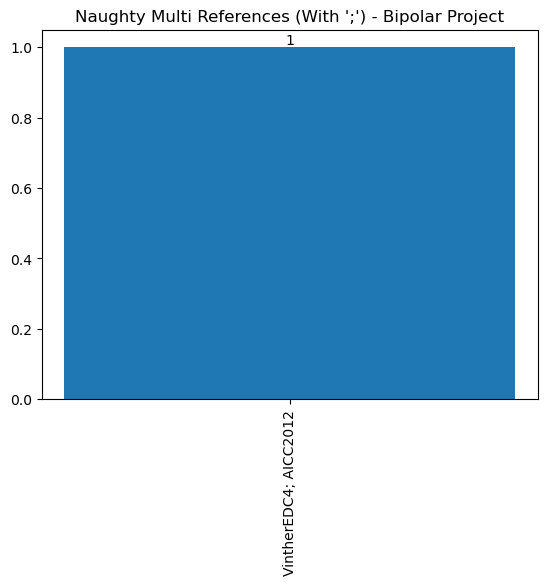

In [407]:
# reference bar plot (only multi references — ';')

full_refs_grab = []
for idx in appended_naughty:
    ref = get_reference(idx)
    full_refs_grab.append(ref)

single_refs = [r for r in full_refs_grab if ";" in r]

print(len(single_refs))
counts_single = Counter(single_refs)

sorted_items = sorted(counts_single.items(), key=lambda x: x[1], reverse=True)
labels = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]

plt.figure()
bars = plt.bar(labels, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=90)
plt.title(f"Naughty Multi References (With ';') - {project} Project")
plt.show()

In [408]:
# depths ratio bar plot

if project == 'Antarctic':
    depths = data['max_depths']
    depth_ratio = []
    order = ['EDC', 'WDC', 'EDML', 'DF', 'TALDICE']
    for idx in appended_naughty:
        ref = get_reference(idx)
        cores_row = big_table.loc[idx].dropna()
        core1 = cores_row.index[0].split("-")[0]
        core2 = cores_row.index[0].split("-")[1].split("_")[0]
        core1_depth = get_depth(core1, idx)
        core2_depth = get_depth(core2, idx)
        if core1 in order and core2 in order:
            core1_order = order.index(core1)
            core2_order = order.index(core2)
            core1_max = depths[core1_order]
            core2_max = depths[core2_order]
            
        ratio1 = core1_depth/core1_max
        ratio2 = core2_depth/core2_max
        for r in (ratio1, ratio2):
            depth_ratio.append(r)


    from matplotlib.ticker import PercentFormatter


    plt.figure()
    bars = plt.hist(depth_ratio, bins=40, weights=100*np.ones(len(depth_ratio)) / len(depth_ratio))

    plt.xticks(rotation=0)
    plt.xlabel("Depth of Tiepoint / Max Depth of Core")
    plt.ylabel("Frequency (%)")
    plt.title(f"Antarctic Naughty Tiepoint Depth Ratios - {project} Project")
    plt.show()
else:
    print("Depth ratio plot only available for Antarctic project, since it requires max depth data for each core.")

Depth ratio plot only available for Antarctic project, since it requires max depth data for each core.


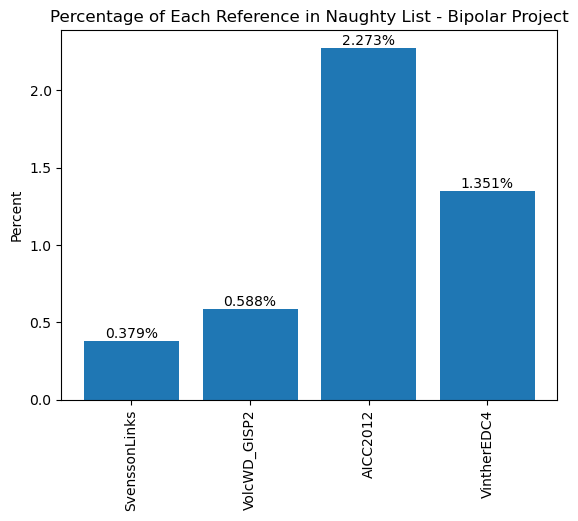

In [409]:
all_refs = []
for idx, row in big_table.iterrows():
    ref = get_reference(idx)
    r_split = ref.split("; ")
    for r in r_split:
        all_refs.append(r)

all_counts = Counter(all_refs)
all_dict = dict(all_counts)

naughty_refs = []
for idx in appended_naughty:
    ref = get_reference(idx)
    r_split = ref.split("; ")
    for r in r_split:
        naughty_refs.append(r)

naughty_counts = Counter(naughty_refs)
naughty_dict = dict(naughty_counts)

names = []
percentages = []
for c, v in naughty_dict.items():
    names.append(c)
    percentages.append(100*v/all_dict[f'{c}'])

bars = plt.bar(names, percentages)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=90)
plt.ylabel("Percent")
plt.title(f"Percentage of Each Reference in Naughty List - {project} Project")
plt.show()
    

In [410]:
wrong = pd.read_csv(f'/Users/quinnmackay/Documents/GitHub/BICC/Antarctic Chronology Accuracy Project/table_out/network analysis files/guaranteed_incorrect_{project}.txt', header=None)
wrong = np.array(wrong[0].tolist())

na=0
ni=0
ni_list_gu = set()
na_list = set()
none=0
for w in wrong:
    if w in nice_list:
        #print(f"ERROR: Code {w} is in nice list.")
        ni+=1
        ni_list_gu.add(w)
    if w in naughty_list:
        #print(f"Code {w} is in naughty list, as expected.")
        na+=1
        na_list.add(w)
    if w not in naughty_list and w not in nice_list:
        #print(f"ERROR: Code {w} is in neither naughty nor nice list.")
        none+=1

print(f"'Guaranteed' Errors by List")
print(f"Total in naughty list: {na}")
print(f"Total in nice list: {ni}")
print(f"Total in neither list: {none}")

print(len(wrong))
for n in na_list:
    print(get_code(n))


'Guaranteed' Errors by List
Total in naughty list: 3
Total in nice list: 0
Total in neither list: 0
3
NG2-EDML_140
GISP2-WDC_161
NG2-EDML_16


In [411]:
na=0
ni=0
none=0
for w in all_first_order:
    if w in nice_list:
        #print(f"ERROR: Code {w} is in nice list.")
        ni+=1
    if w in naughty_list:
        #print(f"Code {w} is in naughty list, as expected.")
        na+=1
    if w not in naughty_list and w not in nice_list:
        #print(f"ERROR: Code {w} is in neither naughty nor nice list.")
        none+=1

print(f'First Order Errors by List')
print(f"Total in naughty list: {na}")
print(f"Total in nice list: {ni}")
print(f"Total in neither list: {none}")

First Order Errors by List
Total in naughty list: 4
Total in nice list: 4
Total in neither list: 4


In [412]:
##AI GEN

table_out_dir = Path('/Users/quinnmackay/Documents/GitHub/BICC/Antarctic Chronology Accuracy Project/table_out')
legend_xlsx = table_out_dir / f'{project}_full.xlsx'
if not legend_xlsx.exists():
    candidates = sorted(table_out_dir.glob('*_full.xlsx'))
    project_prefix = f'{project}_full'.lower()
    legend_xlsx = next((p for p in candidates if p.stem.lower() == project_prefix), None)
    if legend_xlsx is None:
        legend_xlsx = next((p for p in candidates if p.stem.lower().startswith(project.lower())), None)
    if legend_xlsx is None:
        raise FileNotFoundError(f'Could not find a legend workbook for project: {project}')

export_path = Path(f'/Users/quinnmackay/Desktop/{project} Tiepoint Decision Sheet.xlsx')

# Build map: tiepoint code -> list of legend indexes from sheet 2 ('Legend, Stats, and References').
legend_df = pd.read_excel(
    legend_xlsx,
    sheet_name='Legend, Stats, and References',
    header=None,
    engine='openpyxl'
)

header_row_idx = None
index_header_positions = []
for row_idx, row in legend_df.iterrows():
    labels = [str(v).strip().lower() if pd.notna(v) else '' for v in row.tolist()]
    hits = [i for i, label in enumerate(labels) if label == 'index']

    if len(hits) >= 2:
        header_row_idx = row_idx
        index_header_positions = hits
        break

    if hits and header_row_idx is None:
        header_row_idx = row_idx
        index_header_positions = hits

if not index_header_positions:
    raise ValueError("Could not find an 'Index' column in 'Legend, Stats, and References'.")

if len(index_header_positions) >= 2:
    index_col = index_header_positions[1]  # Use second Index when sheet has ref block + code block.
else:
    index_col = index_header_positions[0]

code_start_col = index_col + 1

code_to_indexes = defaultdict(list)
for _, row in legend_df.iloc[header_row_idx + 1:].iterrows():
    if len(row) <= index_col:
        continue

    row_index = row.iloc[index_col]
    if pd.isna(row_index):
        continue
    if str(row_index).strip().lower() == 'index':
        continue

    row_codes = row.iloc[code_start_col:]
    for code in row_codes:
        if pd.isna(code):
            continue
        code_str = str(code).strip()
        if code_str:
            code_to_indexes[code_str].append(row_index)

# Support both possible wrong formats:
# - index values (used by the "Guaranteed Errors by List" checks)
# - code strings
wrong_index_set = set()
wrong_code_set = set()
for x in wrong:
    if pd.isna(x):
        continue
    x_str = str(x).strip()
    if not x_str:
        continue

    wrong_code_set.add(x_str)
    try:
        wrong_index_set.add(int(float(x_str)))
    except ValueError:
        pass


def build_first_order_conflict_groups(index_set):
    row_index_list = []
    group_key_list = []
    depth1_list = []
    depth2_list = []

    for idx in sorted(index_set):
        row = big_table.loc[idx].dropna()
        row_index_list.append(int(idx))
        group_key_list.append(row.index[0])
        depth1_list.append(float(row.iloc[0]))
        depth2_list.append(float(row.iloc[1]))

    groups = defaultdict(list)
    for position, group_key in enumerate(group_key_list):
        groups[group_key].append(position)

    adjacency = defaultdict(set)
    for idx in row_index_list:
        adjacency[idx]

    for group_key, positions in groups.items():
        if len(positions) < 2:
            continue

        idx_arr = np.array([row_index_list[p] for p in positions], dtype=np.int64)
        depth1_arr = np.array([depth1_list[p] for p in positions], dtype=float)
        depth2_arr = np.array([depth2_list[p] for p in positions], dtype=float)

        check1 = np.abs(depth1_arr[:, None] - depth1_arr[None, :]) <= error_margin
        check2 = np.abs(depth2_arr[:, None] - depth2_arr[None, :]) <= error_margin
        xor_matrix = np.logical_xor(check1, check2)
        np.fill_diagonal(xor_matrix, False)

        for row_i, idx in enumerate(idx_arr):
            flagged = np.flatnonzero(xor_matrix[row_i])
            for col_j in flagged:
                idx_check = int(idx_arr[col_j])
                adjacency[int(idx)].add(idx_check)
                adjacency[idx_check].add(int(idx))

    conflict_group_by_idx = {}
    next_group_id = 0

    for start_idx in sorted(row_index_list):
        if start_idx in conflict_group_by_idx:
            continue

        next_group_id += 1
        stack = [start_idx]
        conflict_group_by_idx[start_idx] = next_group_id

        while stack:
            current_idx = stack.pop()
            for neighbor in sorted(adjacency[current_idx]):
                if neighbor not in conflict_group_by_idx:
                    conflict_group_by_idx[neighbor] = next_group_id
                    stack.append(neighbor)

    return conflict_group_by_idx


def build_export_df(index_set, conflict_group_by_idx=None):
    rows = []
    for idx in sorted(index_set):
        code = get_code(idx)
        code_str = str(code).strip()

        core1, core2 = get_row_cores(idx)
        depth1 = get_depth(core1, idx)
        depth2 = get_depth(core2, idx)

        legend_indexes = code_to_indexes.get(code_str, [])
        guaranteed_match = (int(idx) in wrong_index_set) or (code_str in wrong_code_set)
        in_both_lists = (int(idx) in naughty_list) and (int(idx) in all_first_order)

        row_data = {
            'code': code_str,
            'depth1': depth1,
            'depth2': depth2,
            'reference': get_reference(idx),
            'guaranteed_incorrect': guaranteed_match,
            'in_both_lists': in_both_lists,
            'Network Indices': '; '.join(str(v) for v in legend_indexes),
            'Decision': ''
        }

        if conflict_group_by_idx is not None:
            row_data['_conflict_group'] = conflict_group_by_idx.get(int(idx), 10**9)
            row_data['_source_index'] = int(idx)

        rows.append(row_data)

    return pd.DataFrame(rows)


def _is_true_like(value):
    if isinstance(value, bool):
        return value
    return str(value).strip().lower() == 'true'


def format_export_sheet(ws, break_rows=None):
    red_fill = PatternFill(start_color='FFFF0000', end_color='FFFF0000', fill_type='solid')
    yellow_fill = PatternFill(start_color='FFFFFF00', end_color='FFFFFF00', fill_type='solid')
    green_fill = PatternFill(start_color='FF00B050', end_color='FF00B050', fill_type='solid')
    blue_fill = PatternFill(start_color='FF0070C0', end_color='FF0070C0', fill_type='solid')

    header_to_col = {}
    for col_idx in range(1, ws.max_column + 1):
        header_val = ws.cell(row=1, column=col_idx).value
        header_to_col[header_val] = col_idx

    guaranteed_col = header_to_col.get('guaranteed_incorrect')
    if guaranteed_col is not None:
        for row_idx in range(2, ws.max_row + 1):
            cell = ws.cell(row=row_idx, column=guaranteed_col)
            if _is_true_like(cell.value):
                cell.fill = red_fill
            else:
                cell.fill = yellow_fill

    in_both_col = header_to_col.get('in_both_lists')
    if in_both_col is not None:
        for row_idx in range(2, ws.max_row + 1):
            cell = ws.cell(row=row_idx, column=in_both_col)
            if _is_true_like(cell.value):
                cell.fill = green_fill
            else:
                cell.fill = blue_fill

    if break_rows:
        separator_top = Side(style='medium', color='FF000000')
        for row_idx in break_rows:
            for col_idx in range(1, ws.max_column + 1):
                cell = ws.cell(row=row_idx, column=col_idx)
                cell.border = Border(
                    left=cell.border.left,
                    right=cell.border.right,
                    top=separator_top,
                    bottom=cell.border.bottom
                )

    decision_col = header_to_col.get('Decision')
    if decision_col is not None:
        thin_side = Side(style='thin', color='FF000000')
        for row_idx in range(1, ws.max_row + 1):
            cell = ws.cell(row=row_idx, column=decision_col)
            top_side = cell.border.top if cell.border.top.style else thin_side
            cell.border = Border(
                left=thin_side,
                right=thin_side,
                top=top_side,
                bottom=thin_side
            )

    for col_idx in range(1, ws.max_column + 1):
        letter = get_column_letter(col_idx)
        max_len = 0
        for row_idx in range(1, ws.max_row + 1):
            value = ws.cell(row=row_idx, column=col_idx).value
            if value is None:
                continue
            max_len = max(max_len, len(str(value)))

        header_val = ws.cell(row=1, column=col_idx).value
        if header_val is None or str(header_val).strip() == '':
            ws.column_dimensions[letter].width = max(14, min(max_len + 2, 120))
        else:
            ws.column_dimensions[letter].width = min(max_len + 2, 120)


naughty_df = build_export_df(naughty_list)

first_order_conflict_groups = build_first_order_conflict_groups(all_first_order)
first_order_df_full = build_export_df(all_first_order, conflict_group_by_idx=first_order_conflict_groups)
first_order_df_full = first_order_df_full.sort_values(by=['_conflict_group', '_source_index']).reset_index(drop=True)

conflict_group_vals = first_order_df_full['_conflict_group'].tolist()
first_order_break_rows = [
    i + 2
    for i in range(1, len(conflict_group_vals))
    if conflict_group_vals[i] != conflict_group_vals[i - 1]
]

first_order_df = first_order_df_full.drop(columns=['_conflict_group', '_source_index'])

with pd.ExcelWriter(export_path, engine='openpyxl') as writer:
    naughty_df.to_excel(writer, sheet_name='Network Errors', index=False)
    first_order_df.to_excel(writer, sheet_name='First Order Errors', index=False)

    format_export_sheet(writer.sheets['Network Errors'])
    format_export_sheet(writer.sheets['First Order Errors'], break_rows=first_order_break_rows)

print(f'Guaranteed=True in naughty_list export: {int(naughty_df["guaranteed_incorrect"].sum())}')
print(f'Guaranteed=True in all_first_order export: {int(first_order_df["guaranteed_incorrect"].sum())}')
print(f'In-both=True in naughty_list export: {int(naughty_df["in_both_lists"].sum())}')
print(f'In-both=True in all_first_order export: {int(first_order_df["in_both_lists"].sum())}')
print(f'Conflict separators added in all_first_order: {len(first_order_break_rows)}')
print(f'Exported: {export_path}')

Guaranteed=True in naughty_list export: 3
Guaranteed=True in all_first_order export: 3
In-both=True in naughty_list export: 4
In-both=True in all_first_order export: 4
Conflict separators added in all_first_order: 5
Exported: /Users/quinnmackay/Desktop/Bipolar Tiepoint Decision Sheet.xlsx
